In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [25]:
f01_data = pd.read_csv('../data/f01.csv')
f01_data['timestamp'] = pd.to_datetime(f01_data['timestamp'])
f01_data.set_index('timestamp', inplace=True)

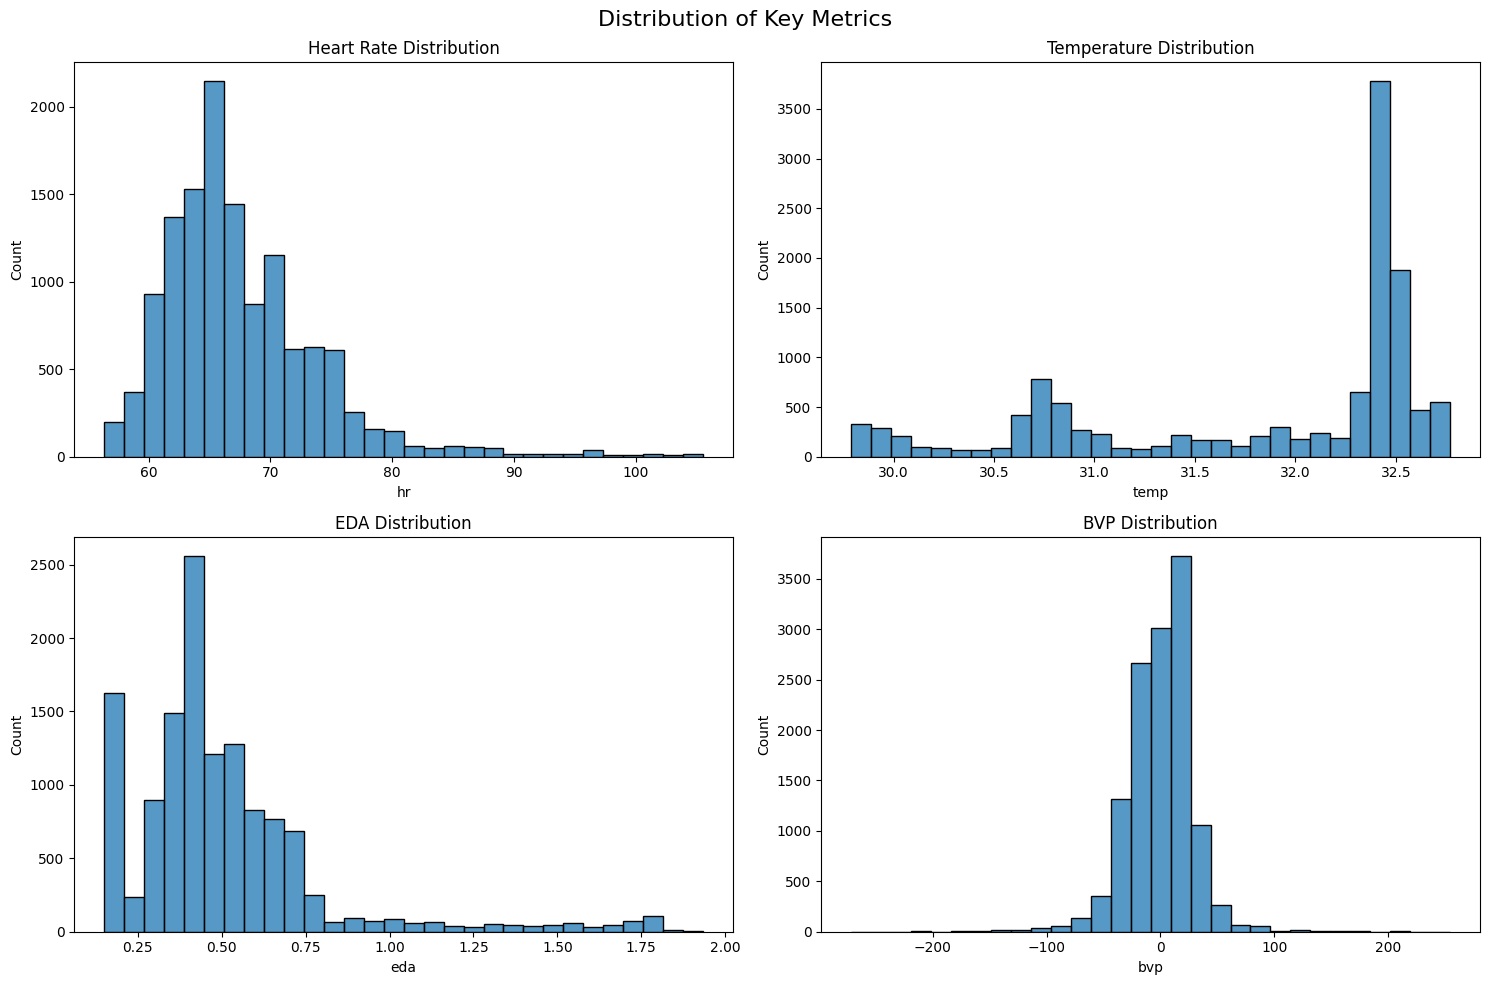

In [26]:
plt.figure(figsize=(15, 10))
plt.suptitle('Distribution of Key Metrics', fontsize=16)

plt.subplot(2, 2, 1)
sns.histplot(data=f01_data, x='hr', bins=30)
plt.title('Heart Rate Distribution')

plt.subplot(2, 2, 2)
sns.histplot(data=f01_data, x='temp', bins=30)
plt.title('Temperature Distribution')

plt.subplot(2, 2, 3)
sns.histplot(data=f01_data, x='eda', bins=30)
plt.title('EDA Distribution')

plt.subplot(2, 2, 4)
sns.histplot(data=f01_data, x='bvp', bins=30)
plt.title('BVP Distribution')

plt.tight_layout()
plt.show()

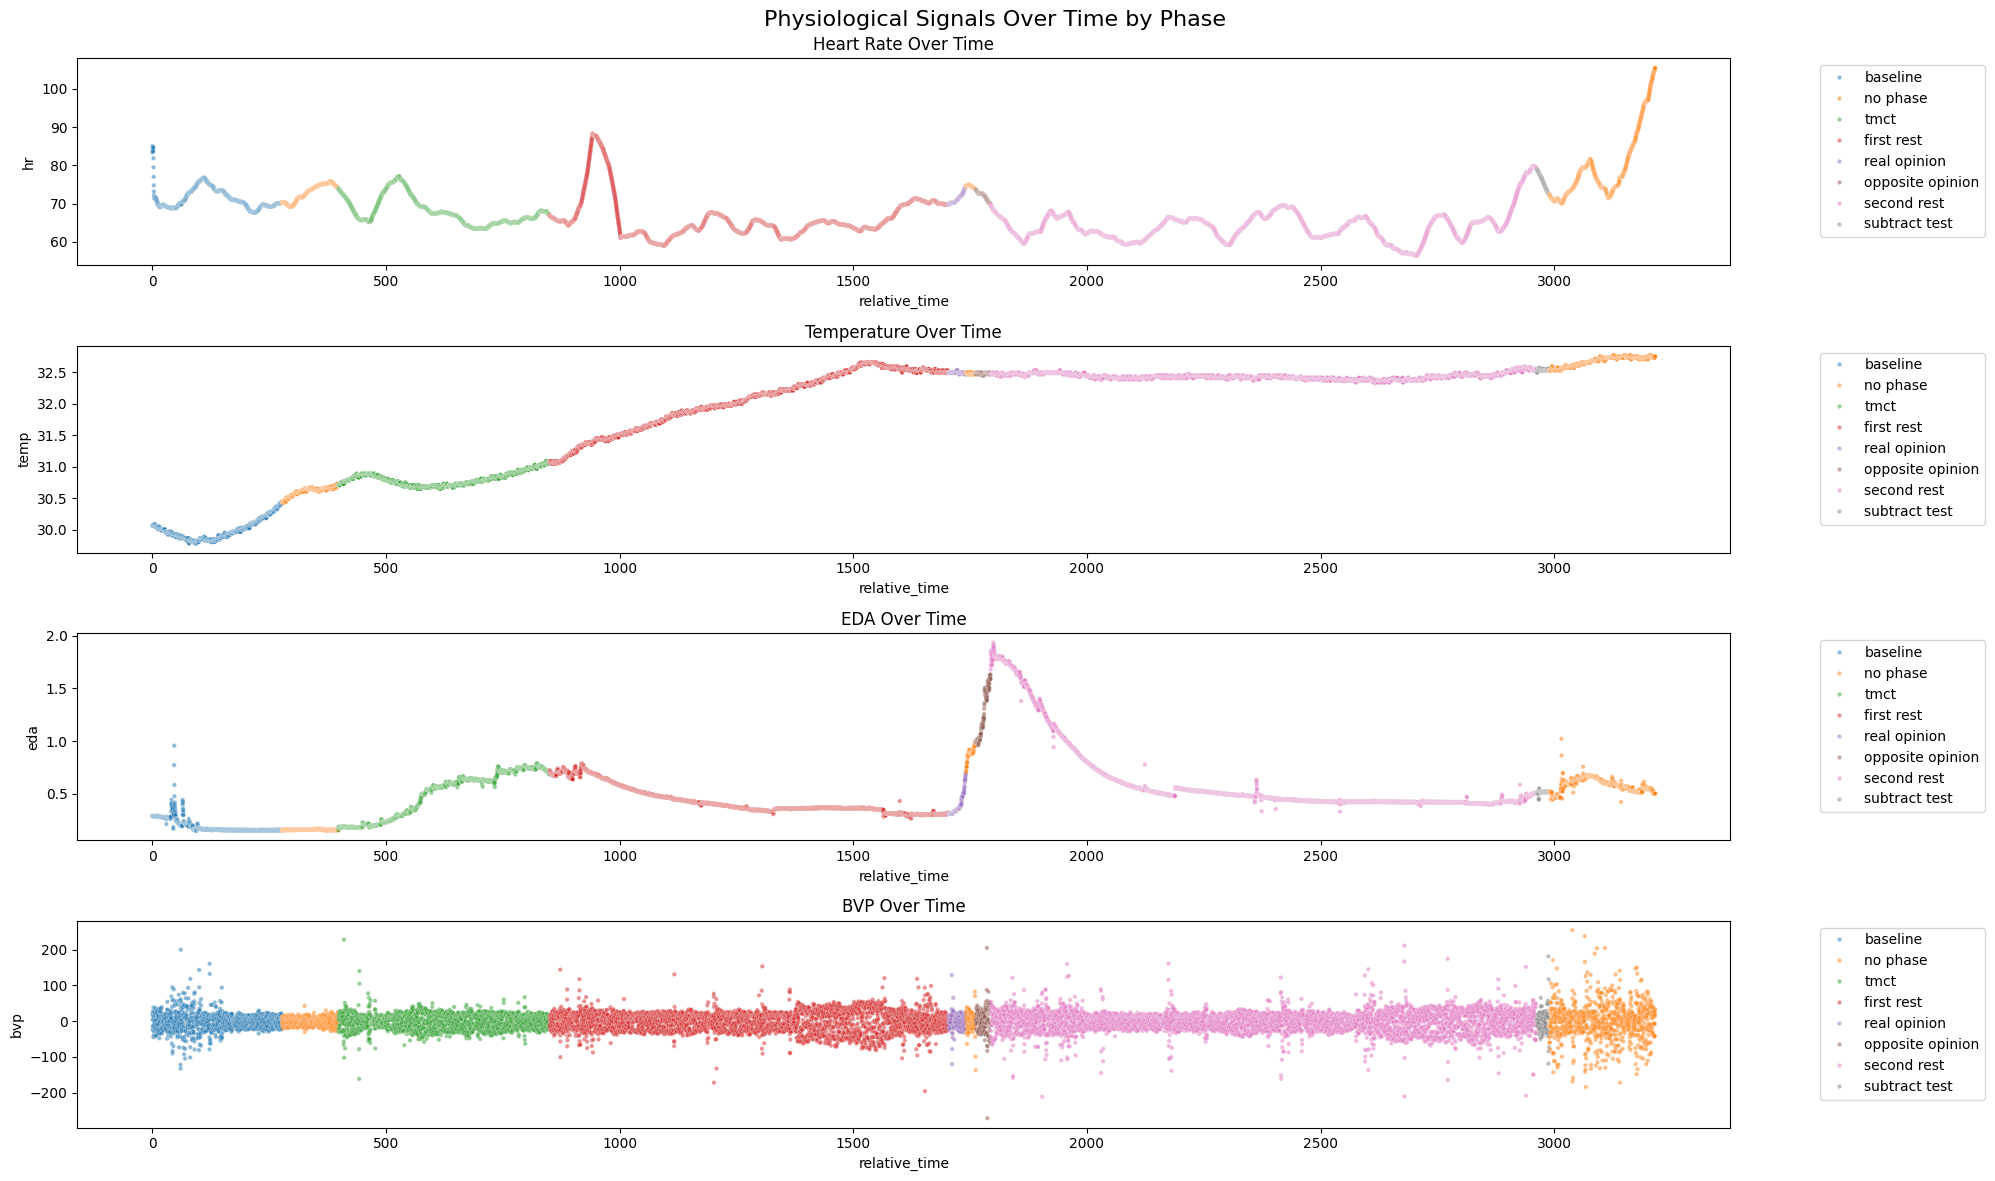

In [27]:
plt.figure(figsize=(20, 12))
plt.suptitle('Physiological Signals Over Time by Phase', fontsize=16)

plt.subplot(4, 1, 1)
sns.scatterplot(data=f01_data, x='relative_time', y='hr', hue='phase', alpha=0.5, s=10, hue_order=f01_data['phase'].unique())
plt.title('Heart Rate Over Time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(4, 1, 2)
sns.scatterplot(data=f01_data, x='relative_time', y='temp', hue='phase', alpha=0.5, s=10, hue_order=f01_data['phase'].unique())
plt.title('Temperature Over Time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(4, 1, 3)
sns.scatterplot(data=f01_data, x='relative_time', y='eda', hue='phase', alpha=0.5, s=10, hue_order=f01_data['phase'].unique())
plt.title('EDA Over Time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(4, 1, 4)
sns.scatterplot(data=f01_data, x='relative_time', y='bvp', hue='phase', alpha=0.5, s=10, hue_order=f01_data['phase'].unique())
plt.title('BVP Over Time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

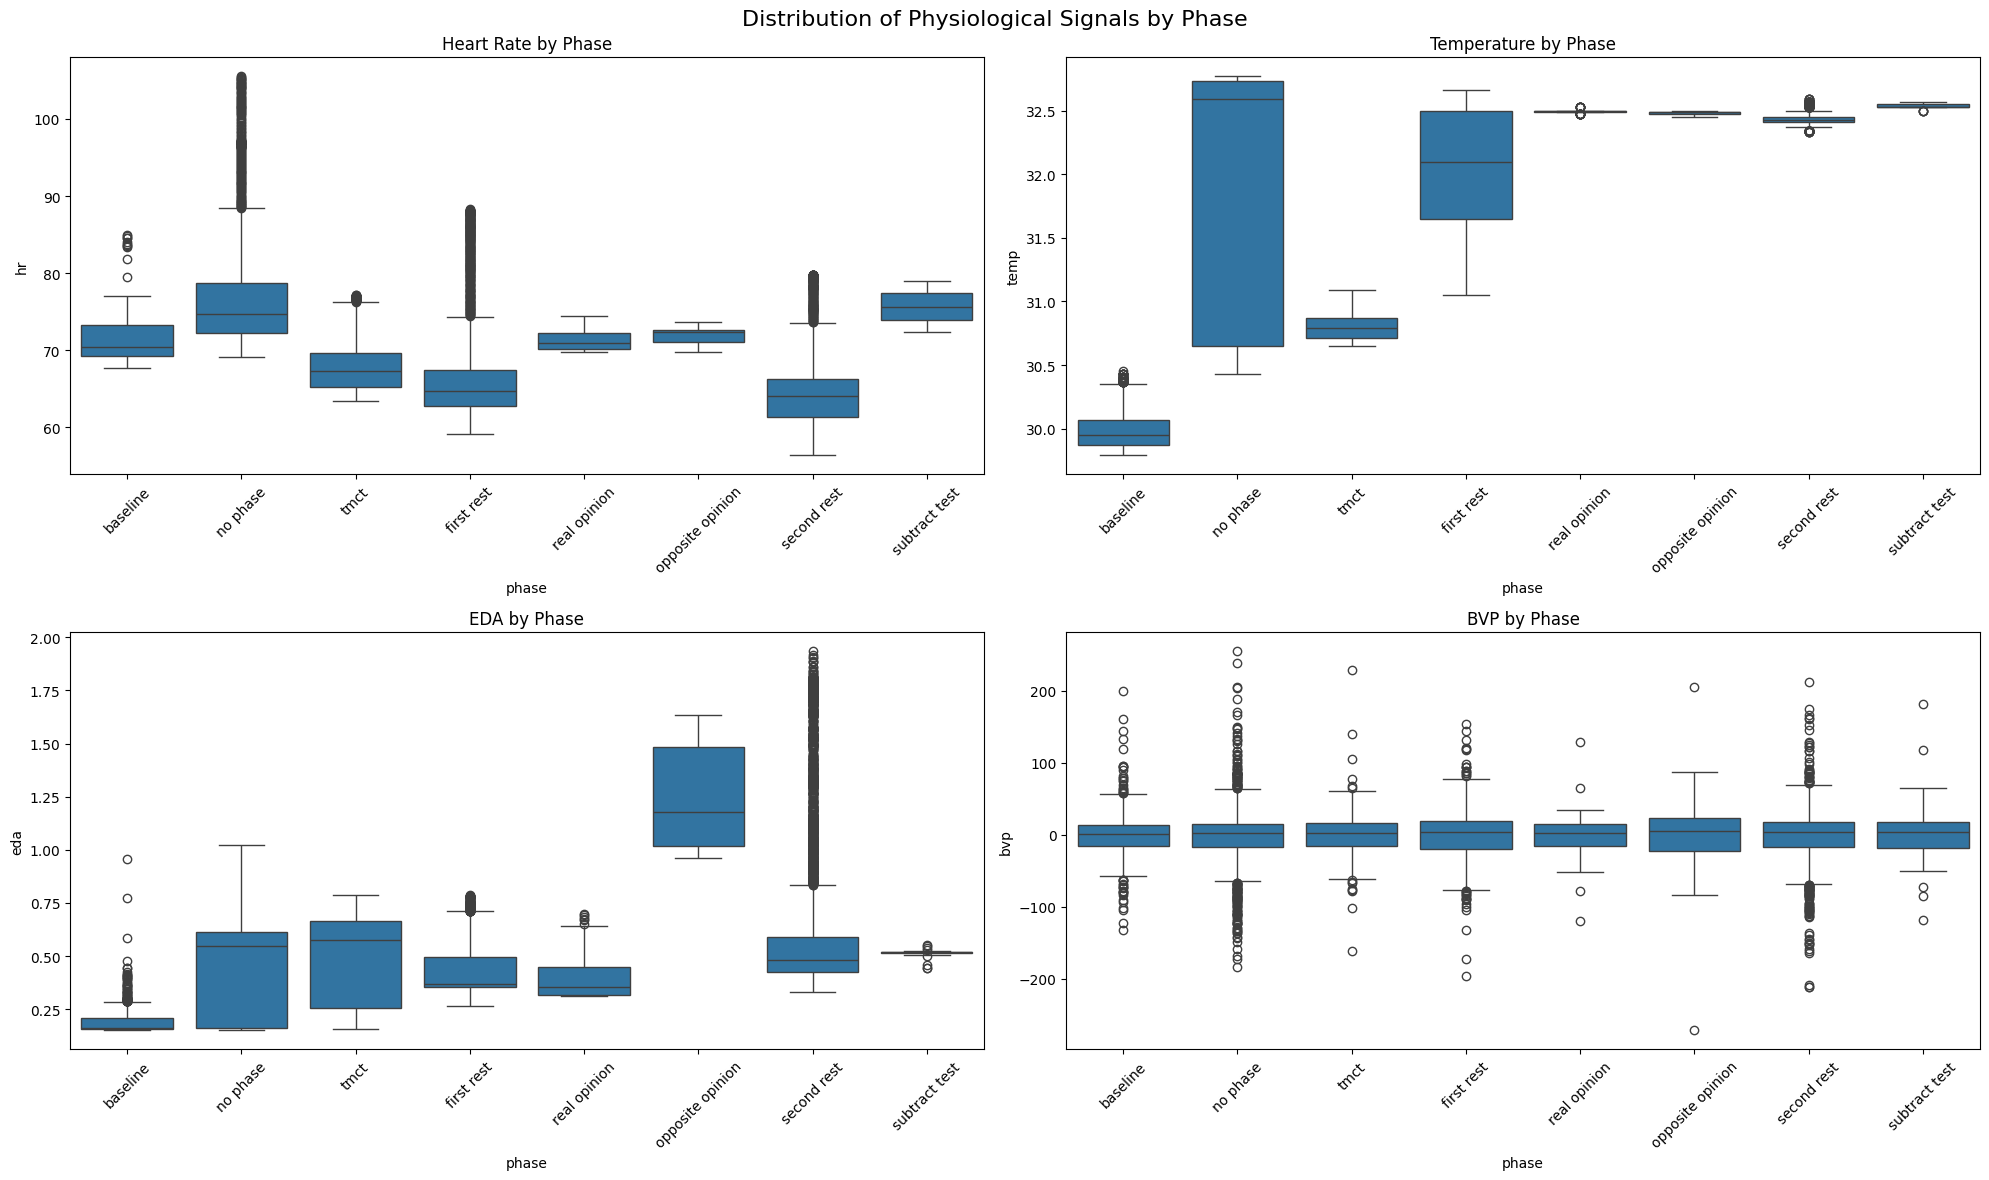

In [28]:
plt.figure(figsize=(20, 12))
plt.suptitle('Distribution of Physiological Signals by Phase', fontsize=16)

plt.subplot(2, 2, 1)
sns.boxplot(data=f01_data, x='phase', y='hr')
plt.xticks(rotation=45)
plt.title('Heart Rate by Phase')

plt.subplot(2, 2, 2)
sns.boxplot(data=f01_data, x='phase', y='temp')
plt.xticks(rotation=45)
plt.title('Temperature by Phase')

plt.subplot(2, 2, 3)
sns.boxplot(data=f01_data, x='phase', y='eda')
plt.xticks(rotation=45)
plt.title('EDA by Phase')

plt.subplot(2, 2, 4)
sns.boxplot(data=f01_data, x='phase', y='bvp')
plt.xticks(rotation=45)
plt.title('BVP by Phase')

plt.tight_layout()
plt.show()

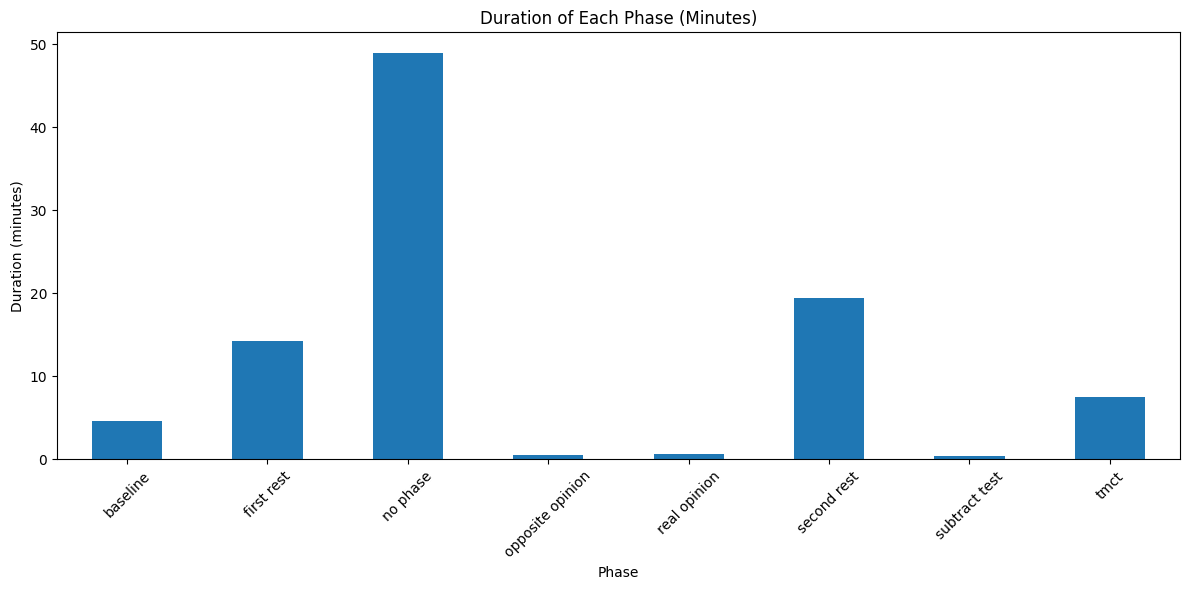

In [29]:
phase_durations = f01_data.groupby('phase').agg({
    'relative_time': lambda x: (x.max() - x.min()) / 60  # Convert to minutes
}).round(2)

plt.figure(figsize=(12, 6))
phase_durations['relative_time'].plot(kind='bar')
plt.title('Duration of Each Phase (Minutes)')
plt.xlabel('Phase')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

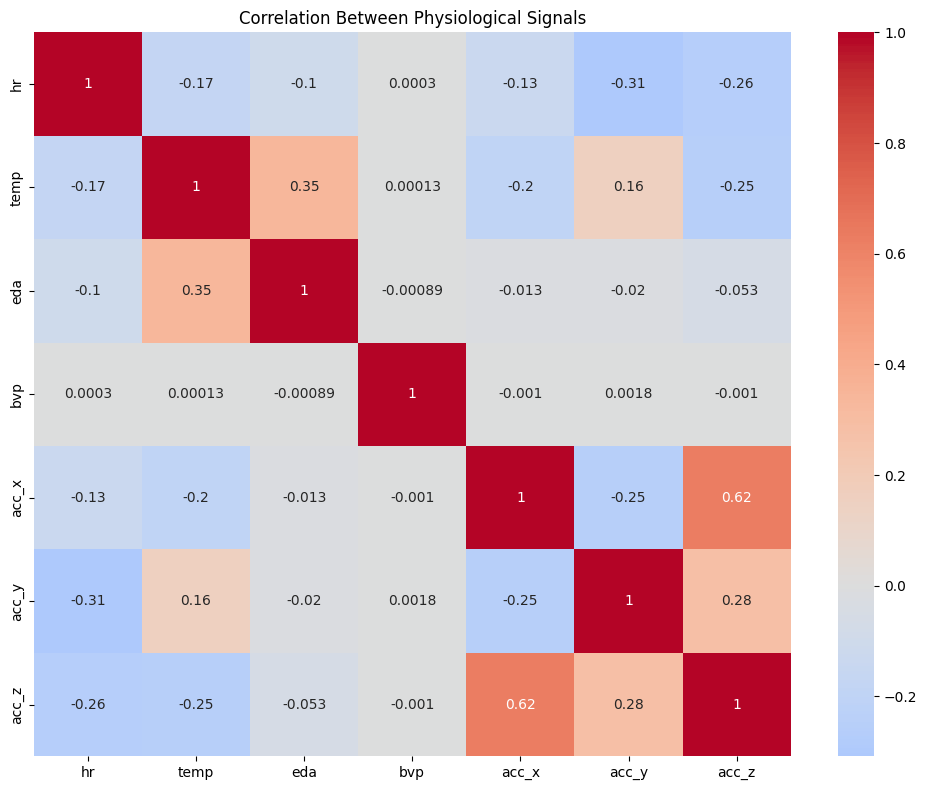

In [30]:
correlation_vars = ['hr', 'temp', 'eda', 'bvp', 'acc_x', 'acc_y', 'acc_z']
correlation_matrix = f01_data[correlation_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Physiological Signals')
plt.tight_layout()
plt.show()


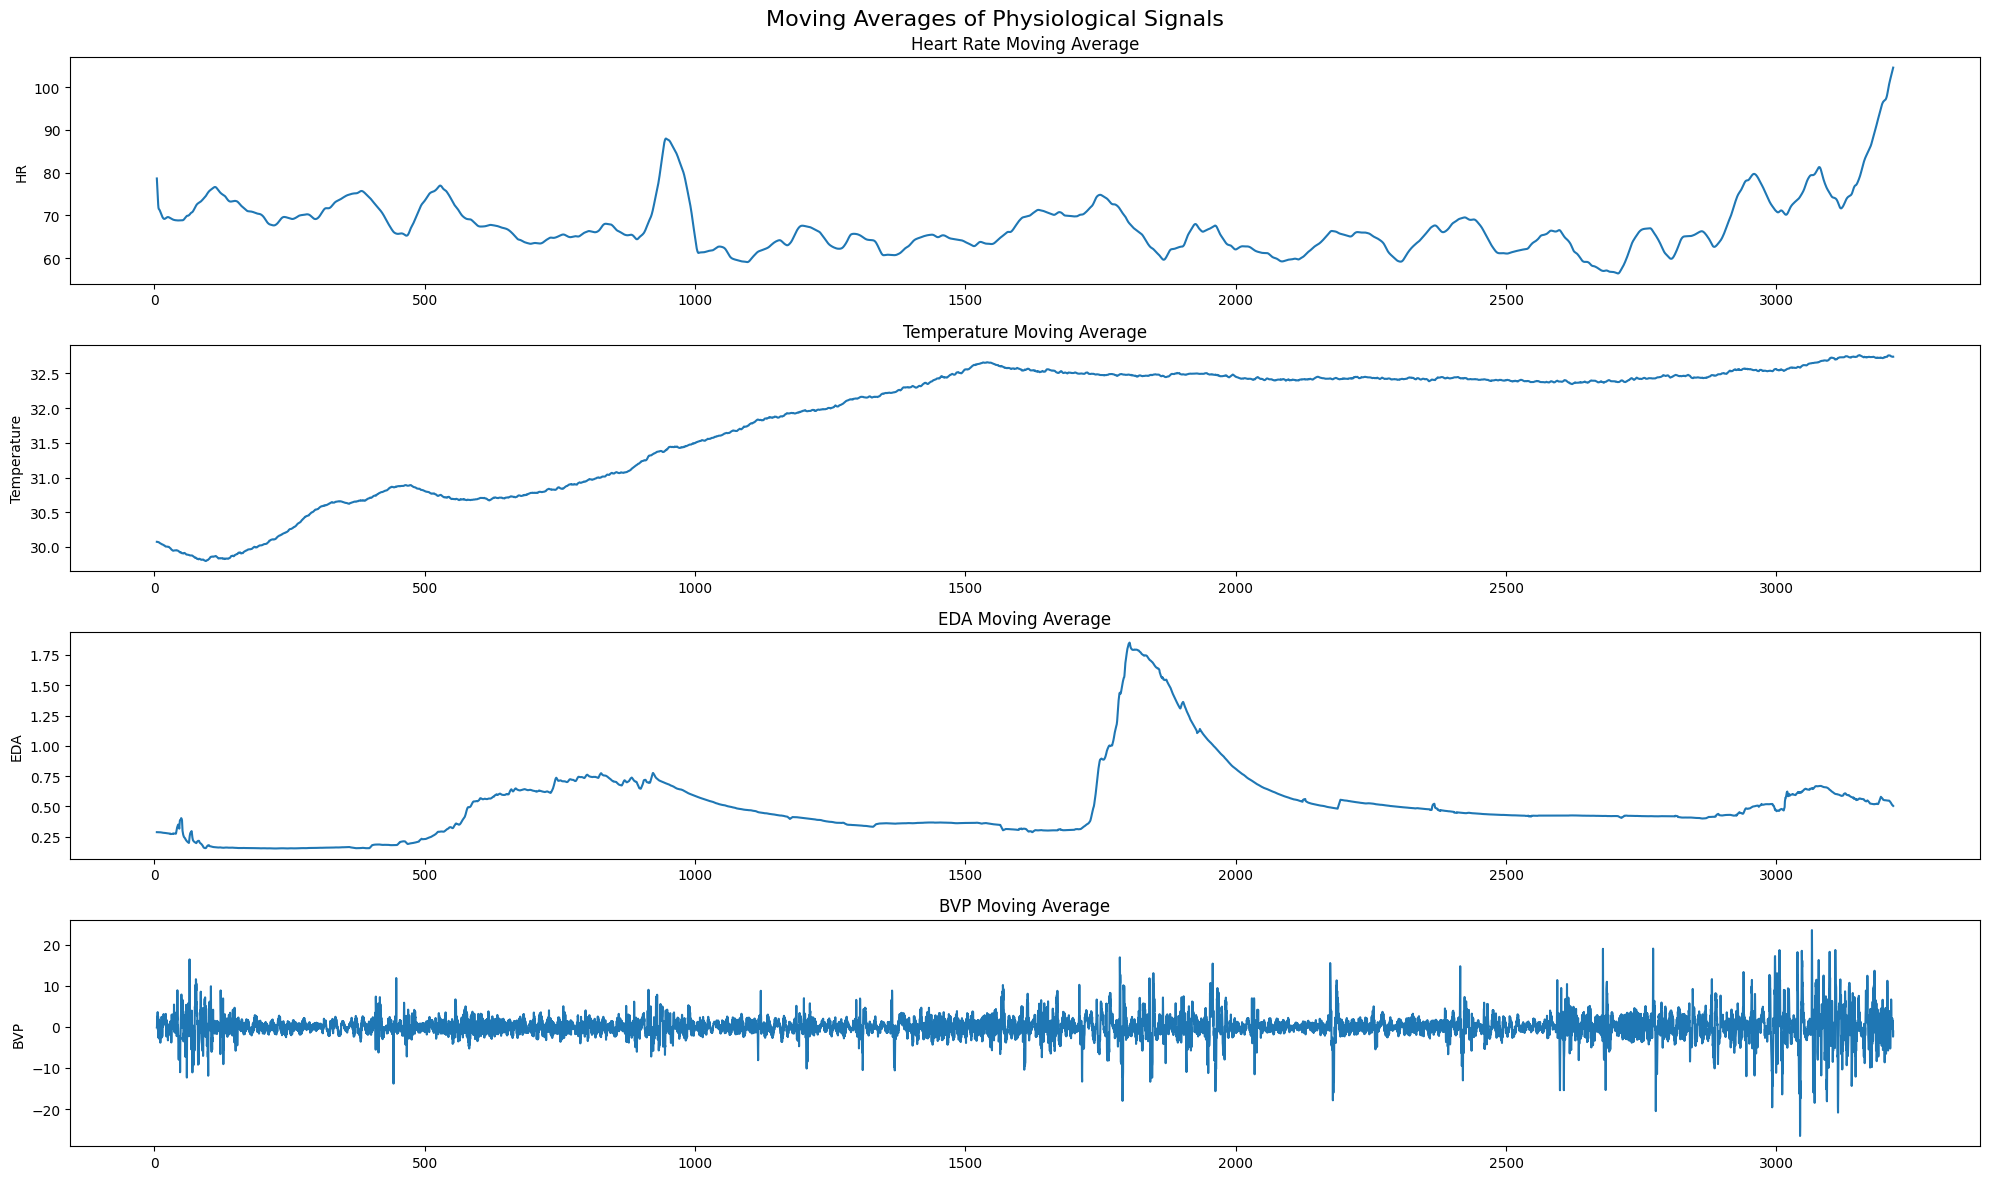

In [31]:
window_size = 20  # 5 seconds at 4Hz
plt.figure(figsize=(20, 12))
plt.suptitle('Moving Averages of Physiological Signals', fontsize=16)

plt.subplot(4, 1, 1)
plt.plot(f01_data['relative_time'], f01_data['hr'].rolling(window=window_size).mean())
plt.title('Heart Rate Moving Average')
plt.ylabel('HR')

plt.subplot(4, 1, 2)
plt.plot(f01_data['relative_time'], f01_data['temp'].rolling(window=window_size).mean())
plt.title('Temperature Moving Average')
plt.ylabel('Temperature')

plt.subplot(4, 1, 3)
plt.plot(f01_data['relative_time'], f01_data['eda'].rolling(window=window_size).mean())
plt.title('EDA Moving Average')
plt.ylabel('EDA')

plt.subplot(4, 1, 4)
plt.plot(f01_data['relative_time'], f01_data['bvp'].rolling(window=window_size).mean())
plt.title('BVP Moving Average')
plt.ylabel('BVP')

plt.tight_layout()
plt.show()